# Persistence
- It refers to the ability to save & restore the state of a workflow over time.
- Persistence does not only stores the final values it also stores all the intermediate values as well. This behaviour helps us in implementing rerty logic (Fault Tolerance) i.e. If the workflow crashes at any step we can again resume/ restart the flow from the same point.
- Persistence is about saving the graph’s state at each step so it can be:
    - Resumed later
    - Inspected/debugged
    - Continued across multiple user interactions
    - Protected from failures (restart from last checkpoint instead of starting over)

### Checkpointers:
- In LangGraph presistence is implemented through checkpointers.
- It divides the complete graph's execution in checkpoints
- At every checkpoint it sves the graph's state
- A checkpointer:
    1. Saves the state after each node execution
    2. Associates it with a thread/session ID
    3. Allows replay or continuation

### Threads:
- A thread is essentially a unique session ID (called thread_id) that:
    1. Groups all checkpoints together
    2. Represents one conversation / workflow run over time
    3. Lets LangGraph load past state and continue from it
- Without threads: 
    1. Every .invoke() is a fresh start.
- With threads:
    1. The graph remembers previous steps
    2. You can ask follow-ups like:
        - “What did I ask before?”
        - “Continue from where we left off”

In [19]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.7)

# State
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

# Node
def generate_joke(state: JokeState):
    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

def generate_explanation(state: JokeState):
    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

# Graph
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

# Now we'll compile the graph with an in-memory checkpointer to enable state saving and resuming.
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

In [20]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was feeling a little crusty.',
 'explanation': 'This joke is a play on words, combining a common phrase used to describe a person\'s emotional state with a characteristic of pizza. \n\nThe phrase "feeling a little crusty" is typically used to describe someone who is a bit grumpy or irritable. However, in the context of the joke, it\'s applied to a pizza, which has a crust as a main component. \n\nThe humor comes from the unexpected twist on the usual phrase, making it a clever and punny play on language. It\'s a lighthearted and simple joke that relies on a quick mental connection between the phrase and the characteristic of the pizza.'}

In [21]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'Summer'}, config=config2)

{'topic': 'Summer',
 'joke': 'Why did the sun go to therapy during summer? \n\nBecause it had a burning issue.',
 'explanation': 'The joke is a play on words, combining a common phrase associated with emotional distress ("burning issue") with the literal meaning of the word "burning" in relation to the sun\'s temperature and its association with fire.\n\nIn everyday usage, a "burning issue" refers to a pressing problem or concern that needs to be addressed. However, in the context of the sun, "burning" has a different meaning, referring to the intense heat and light energy it emits.\n\nThe joke relies on this double meaning to create a pun. The setup "Why did the sun go to therapy during summer?" primes the listener to expect a more serious explanation for the sun\'s actions. Instead, the punchline subverts expectations by using the phrase "burning issue" in a literal sense, referencing the sun\'s fiery nature.\n\nThis type of wordplay is a classic example of a "pun," which relies on m

In [22]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, combining a common phrase used to describe a person\'s emotional state with a characteristic of pizza. \n\nThe phrase "feeling a little crusty" is typically used to describe someone who is a bit grumpy or irritable. However, in the context of the joke, it\'s applied to a pizza, which has a crust as a main component. \n\nThe humor comes from the unexpected twist on the usual phrase, making it a clever and punny play on language. It\'s a lighthearted and simple joke that relies on a quick mental connection between the phrase and the characteristic of the pizza.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f140884-83ba-605d-8002-915233d7a797'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-25T09:22:29.679318+00:00', parent_config={'confi

In [23]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor?\n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words, combining a common phrase used to describe a person\'s emotional state with a characteristic of pizza. \n\nThe phrase "feeling a little crusty" is typically used to describe someone who is a bit grumpy or irritable. However, in the context of the joke, it\'s applied to a pizza, which has a crust as a main component. \n\nThe humor comes from the unexpected twist on the usual phrase, making it a clever and punny play on language. It\'s a lighthearted and simple joke that relies on a quick mental connection between the phrase and the characteristic of the pizza.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f140884-83ba-605d-8002-915233d7a797'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-25T09:22:29.679318+00:00', parent_config={'conf

In [24]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Summer', 'joke': 'Why did the sun go to therapy during summer? \n\nBecause it had a burning issue.', 'explanation': 'The joke is a play on words, combining a common phrase associated with emotional distress ("burning issue") with the literal meaning of the word "burning" in relation to the sun\'s temperature and its association with fire.\n\nIn everyday usage, a "burning issue" refers to a pressing problem or concern that needs to be addressed. However, in the context of the sun, "burning" has a different meaning, referring to the intense heat and light energy it emits.\n\nThe joke relies on this double meaning to create a pun. The setup "Why did the sun go to therapy during summer?" primes the listener to expect a more serious explanation for the sun\'s actions. Instead, the punchline subverts expectations by using the phrase "burning issue" in a literal sense, referencing the sun\'s fiery nature.\n\nThis type of wordplay is a classic example of a "pun,

In [25]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Summer', 'joke': 'Why did the sun go to therapy during summer? \n\nBecause it had a burning issue.', 'explanation': 'The joke is a play on words, combining a common phrase associated with emotional distress ("burning issue") with the literal meaning of the word "burning" in relation to the sun\'s temperature and its association with fire.\n\nIn everyday usage, a "burning issue" refers to a pressing problem or concern that needs to be addressed. However, in the context of the sun, "burning" has a different meaning, referring to the intense heat and light energy it emits.\n\nThe joke relies on this double meaning to create a pun. The setup "Why did the sun go to therapy during summer?" primes the listener to expect a more serious explanation for the sun\'s actions. Instead, the punchline subverts expectations by using the phrase "burning issue" in a literal sense, referencing the sun\'s fiery nature.\n\nThis type of wordplay is a classic example of a "pun

### Benifits of Persistence:
1. Implement Short Term Memory
2. Implement Fault Tolerance
3. Implement HITL (Human-In-The-Loop)
4. Time Travel

### Time Travel
- In time travel we can replay the workflow execution 
- We can also go to the particular checkpoint using the 'get_state_history' & get the checkpoint_id.

In [26]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f140884-7aca-62ef-8000-a2947918beb9"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f140884-7aca-62ef-8000-a2947918beb9'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-25T09:22:28.742218+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f140884-7aca-62ee-bfff-6cd3eb18aea9'}}, tasks=(PregelTask(id='01e4488f-f4b0-c818-bbcf-28e5e919036a', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza go to the doctor?\n\nBecause it was feeling a little crusty.'}),), interrupts=())

In [27]:
# Resuming from a checkpoint
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f140884-7aca-62ef-8000-a2947918beb9"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to the doctor? \n\nIt was feeling a little crusty.',
 'explanation': 'This joke is an example of wordplay, a type of humor that relies on using words in a way that plays with their meanings or sounds.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning:\n\n1. In everyday language, "crusty" can describe something or someone that is a bit rough or gruff on the outside, often due to age or wear and tear.\n2. A pizza has a crust, which is the outer layer of the bread that makes up the pizza.\n\nThe joke plays on this double meaning by using the phrase "feeling a little crusty" to describe a pizza that\'s going to the doctor. The punchline is funny because it takes the common phrase and gives it a literal twist, referencing the pizza\'s crust. The humor comes from the unexpected connection between the wordplay and the situation.'}

In [28]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nIt was feeling a little crusty.', 'explanation': 'This joke is an example of wordplay, a type of humor that relies on using words in a way that plays with their meanings or sounds.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning:\n\n1. In everyday language, "crusty" can describe something or someone that is a bit rough or gruff on the outside, often due to age or wear and tear.\n2. A pizza has a crust, which is the outer layer of the bread that makes up the pizza.\n\nThe joke plays on this double meaning by using the phrase "feeling a little crusty" to describe a pizza that\'s going to the doctor. The punchline is funny because it takes the common phrase and gives it a literal twist, referencing the pizza\'s crust. The humor comes from the unexpected connection between the wordplay and the situation.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns':

In [29]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f140884-7aca-62ef-8000-a2947918beb9", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14088e-e6c4-6b88-8001-26428bfc309a'}}

In [30]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14088e-e6c4-6b88-8001-26428bfc309a'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-25T09:27:08.500058+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f140884-7aca-62ef-8000-a2947918beb9'}}, tasks=(PregelTask(id='32bd3a02-ae6e-ce86-84dd-f636c240f228', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to the doctor? \n\nIt was feeling a little crusty.', 'explanation': 'This joke is an example of wordplay, a type of humor that relies on using words in a way that plays with their meanings or sounds.\n\nIn this joke, the phrase "feeling a little crusty" has a double meaning:\n\n1. In everyday language, "crus

In [31]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f14088e-e6c4-6b88-8001-26428bfc309a"}})

{'topic': 'samosa',
 'joke': 'Why did the samosa go to therapy? \n\nBecause it was feeling crumby.',
 'explanation': "The joke relies on a play on words. 'Crumby' has a double meaning here:\n\n1. In a literal sense, a samosa is a type of fried or baked pastry, and when it's not fresh, it can become crumbly. So, a crumby samosa would be one that's fallen apart or is no longer in good condition.\n\n2. In an idiomatic sense, 'feeling crumby' is a common phrase used to describe someone who feels unwell, sad, or down. It's an informal way of saying that someone isn't feeling their best.\n\nThe joke works because it takes the literal meaning of 'crumby' (a characteristic of a samosa) and applies it to the idiomatic meaning (feeling unwell). The punchline 'was feeling crumby' is a clever play on words that connects the idea of the samosa's physical state to its emotional state. This wordplay creates a humorous connection between the setup and the punchline, making the joke amusing."}

In [32]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy? \n\nBecause it was feeling crumby.', 'explanation': "The joke relies on a play on words. 'Crumby' has a double meaning here:\n\n1. In a literal sense, a samosa is a type of fried or baked pastry, and when it's not fresh, it can become crumbly. So, a crumby samosa would be one that's fallen apart or is no longer in good condition.\n\n2. In an idiomatic sense, 'feeling crumby' is a common phrase used to describe someone who feels unwell, sad, or down. It's an informal way of saying that someone isn't feeling their best.\n\nThe joke works because it takes the literal meaning of 'crumby' (a characteristic of a samosa) and applies it to the idiomatic meaning (feeling unwell). The punchline 'was feeling crumby' is a clever play on words that connects the idea of the samosa's physical state to its emotional state. This wordplay creates a humorous connection between the setup and the punchline, making the joke

In [33]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to therapy? \n\nBecause it was feeling crumby.', 'explanation': "The joke relies on a play on words. 'Crumby' has a double meaning here:\n\n1. In a literal sense, a samosa is a type of fried or baked pastry, and when it's not fresh, it can become crumbly. So, a crumby samosa would be one that's fallen apart or is no longer in good condition.\n\n2. In an idiomatic sense, 'feeling crumby' is a common phrase used to describe someone who feels unwell, sad, or down. It's an informal way of saying that someone isn't feeling their best.\n\nThe joke works because it takes the literal meaning of 'crumby' (a characteristic of a samosa) and applies it to the idiomatic meaning (feeling unwell). The punchline 'was feeling crumby' is a clever play on words that connects the idea of the samosa's physical state to its emotional state. This wordplay creates a humorous connection between the setup and the punchline, making the joke

### Fault Tolerance

In [8]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

# 1. State
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str
    
# 2. Nodes
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")

    for _ in range(200):
        time.sleep(0.2)  

    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": "done"}

# 3. Graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

# 4. Checkpointer
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

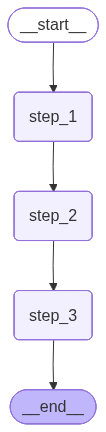

In [9]:
graph

In [10]:
# 5. Invoke the graph and simulate a crash during Step 2
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [11]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140855-3b6f-6e9a-8001-397432ae587f'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-25T09:01:20.452572+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140855-3b6f-6e99-8000-83b7d26ca838'}}, tasks=(PregelTask(id='a3b44fc4-177d-d56e-9860-d46286f200bf', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [12]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140855-3b6f-6e9a-8001-397432ae587f'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-25T09:01:20.452572+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140855-3b6f-6e99-8000-83b7d26ca838'}}, tasks=(PregelTask(id='a3b44fc4-177d-d56e-9860-d46286f200bf', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step_1',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140855-3b6f-6e99-8000-83b7d26ca838'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-25T09:01:20.452572+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'ch

In [13]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [14]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140857-2322-665f-8003-9c2e87c664f7'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-25T09:02:11.591331+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140857-2319-6487-8002-8403aca90e2f'}}, tasks=(), interrupts=())

In [15]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140857-2322-665f-8003-9c2e87c664f7'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-25T09:02:11.591331+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140857-2319-6487-8002-8403aca90e2f'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140857-2319-6487-8002-8403aca90e2f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-25T09:02:11.587597+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f140855-3b6f-6e9a-8001-397432ae587f'}}, tasks=(PregelTask(id='78671537-1bd7-e8b9